# 3.5.2 Shortest Paths from Source to All Other Nodes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1IU7icvzSvD_IZtq8JaCeB-cjqfA3eZ6y?usp=sharing)


&nbsp;&nbsp;&nbsp;&nbsp;A more general algorithm that can be applied to any network having all arc labels non-negative is known as **Dijkstra’s algorithm**. This algorithm begins with the source node and determines the shortest paths from the source to every other node. During the operation of Dijkstra’s algorithm, the nodes are partitioned into two sets: a set, which we shall call S, to contain nodes for which the shortest distance from the source is known, and another set T to contain nodes for which this shortest distance is not yet known. A label p<sub>i</sub> is associated with every node i and specifies the length of the shortest path known *so far* from the source node 1 to node i. Again, we let d<sub>ij</sub> denote the direct distance from node i to node j.

1. Initially, only the source node is placed in set S, and this node is labeled zero, indicating that there is zero distance from the source to itself.

2. Initialize all other labels as follows:

<br>

$$
p_i = d_{1i}
\qquad \text{for } i \ne \text{source node } 1
$$

$$
\text{and } p_i = \infty
\qquad \text{if node } i \text{ is not connected to the source}
$$

<br>

3. Choose a node w, not in set S, whose label p<sub>w</sub> is minimum over all nodes not in S, add node w to S, and adjust the labels for all nodes v, not in set S, as follows:

<br>

$$
p_v = \min \{p_v,\; p_w + d_{wv}\}
$$

<br>

4. Repeat Step 3 until all nodes belong to set S.

<br>

In Step 3, we assume that p<sub>v</sub> is the shortest distance from the source to node v directly through nodes in S. When we add node w to S, we check whether or not the new distance through w is shorter, and update if necessary. We will use the network shown in **Figure 3.16** to illustrate Dijkstra’s algorithm.

&nbsp;&nbsp;&nbsp;&nbsp;Initially S = {1}, and p<sub>1</sub> = 0, p<sub>2</sub> = 5, p<sub>3</sub> = 3, p<sub>4</sub> = 8, p<sub>5</sub> = ∞, and p<sub>6</sub> = ∞. We then choose the minimum label 3 on node 3, and S = {1, 3}. Labels are now

$$
p_2 = \min \{5,\; 3 + \infty\} = 5
$$

$$
p_4 = \min \{8,\; 3 + \infty\} = 8
$$

$$
p_5 = \min \{\infty,\; 3 + 4\} = 7
$$

$$
p_6 = \min \{\infty,\; 3 + 8\} = 11
$$

<br>

&nbsp;&nbsp;&nbsp;&nbsp;In the next iteration, we select the label 5 on node 2, so that S = {1, 3, 2}, and new labels are

<br>

$$
p_4 = \min \{8,\; 5 + 2\} = 7
$$

$$
p_5 = \min \{7,\; 5 + \infty\} = 7
$$

$$
p_6 = \min \{11,\; 5 + \infty\} = 11
$$

<br>

&nbsp;&nbsp;&nbsp;&nbsp;From these labels, we break a tie arbitrarily and select the minimum label 7 on node 5. Now S = {1, 3, 2, 5} and


<div align="center">

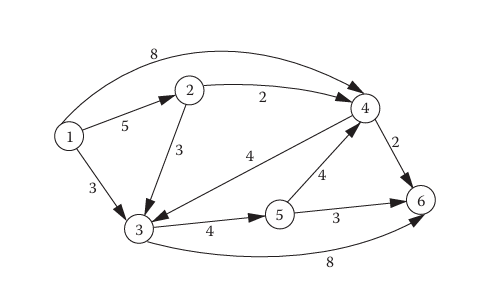

</div>

**FIGURE 3.16** <br>
Shortest path with Dijkstra’s algorithm.

<br>

$$
p_4 = \min \{7,\; 7 + 4\} = 7
$$

$$
p_6 = \min \{11,\; 7 + 3\} = 10
$$

<br>

&nbsp;&nbsp;&nbsp;&nbsp;Now we choose node 4 and S = {1, 3, 2, 5, 4}, and

<br>

$$
p_6 = \min \{10,\; 7 + 2\} = 9
$$

<br>

Finally, node 6 is added to set S. The final labels are p<sub>1</sub> = 0, p<sub>2</sub> = 5, p<sub>3</sub> = 3, p<sub>4</sub> = 7, p<sub>5</sub> = 7, and p<sub>6</sub> = 9, and the values of these labels indicate the lengths of the shortest paths from node 1 to each of the other nodes.

&nbsp;&nbsp;&nbsp;&nbsp;On a dense graph of n nodes and e arcs, represented by an adjacency matrix, Dijkstra’s algorithm executes in time O(n<sup>2</sup>). In a sparse network where e is much less than n<sup>2</sup>, it is worthwhile to represent the graph as an adjacency list, and to manage the node partitions using a priority queue implemented as a partially ordered tree. In that case, the running time is O(e log n).

&nbsp;&nbsp;&nbsp;&nbsp;The proof of optimality of Dijkstra’s algorithm requires that all the arcs have positive labels. But consider a network in which arcs represent stages of a journey. Along certain arcs a cost is incurred, positive cost, while on other arcs it is possible to turn a profit, negative costs. Our objective would be to find a minimum cost path from source to destination and, if possible, a path with negative cost, for example path. An algorithm developed by Bellman and Ford will solve this problem as long as there is no cycle in which the sum of the arc lengths is negative. Observe that, if there were a cycle with a negative total length, then we could simply travel around the cycle indefinitely, reducing our cost with no lower bound.

&nbsp;&nbsp;&nbsp;&nbsp;Suppose we have a network for which we would like to know the shortest distance between *any* two nodes. This is called the *all-pairs* shortest path problem. For this problem, Dijkstra’s algorithm could be applied n times, using a different node each time as the source, to obtain the desired result in time O(n<sup>3</sup>). Another algorithm known as Floyd’s algorithm provides the solution in a more direct way, also in time O(n<sup>3</sup>) but with a much lower constant factor than Dijkstra’s algorithm. However, for large sparse graphs, clever use of data structures will allow Dijkstra’s algorithm to operate in O(n e log n) time. Algorithms for the second shortest path through a network, the n-th shortest path, and for all possible paths between two specified nodes, are described and illustrated in Price (1971).

In [1]:
# ========================================
# 3.5.2 Shortest Path Algorithms
# Dijkstra | Bellman-Ford | Floyd (All-Pairs)
# ========================================

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

print('Libraries loaded successfully.')
print('NetworkX version:', nx.__version__)


Libraries loaded successfully.
NetworkX version: 3.6.1


In [2]:
# ========================================
# Book Example — Figure 3.16
# Undirected weighted graph, nodes 1–6
# Shortest path from 1 to 6 = 9  (1 → 3 → 4 → 6)
# ========================================

edge_list = [
    (1, 2, 5),
    (1, 3, 3),
    (1, 4, 8),
    (2, 4, 2),
    (2, 3, 3),
    (3, 5, 4),
    (3, 6, 8),
    (4, 3, 4),
    (4, 6, 2),
    (5, 6, 3),
    (5, 4, 4)
]

source = 1
dest   = 6

G = nx.Graph()
for u, v, w in edge_list:
    G.add_edge(u, v, weight=w)

print('Book example (Figure 3.16) network created.')
print(f'Source: {source}   Destination: {dest}')
print()
display(pd.DataFrame(edge_list, columns=['Node i', 'Node j', 'Weight']))

Book example (Figure 3.16) network created.
Source: 1   Destination: 6



,Node i,Node j,Weight
0,1,2,5
1,1,3,3
2,1,4,8
3,2,4,2
4,2,3,3
5,3,5,4
6,3,6,8
7,4,3,4
8,4,6,2
9,5,6,3


In [3]:
# ========================================
# Algebraic Method: Manual Dijkstra's Algorithm
# Step-by-step label-setting, mirroring the textbook.
# ========================================

import heapq

def dijkstra_manual(G, source):
    """
    Dijkstra's algorithm with step-by-step output.
    Works on undirected or directed graphs with non-negative weights.
    """
    labels   = {n: float('inf') for n in G.nodes()}
    prev     = {n: None         for n in G.nodes()}
    visited  = set()
    labels[source] = 0

    heap = [(0, source)]
    step = 0

    while heap:
        dist_k, k = heapq.heappop(heap)
        if k in visited:
            continue
        visited.add(k)
        step += 1
        print(f'Step {step}: choose node {k}  (p_{k} = {dist_k}),  S = {sorted(visited)}')

        for j in G.neighbors(k):
            w = G[k][j]['weight']
            new_dist = dist_k + w
            if new_dist < labels[j]:
                labels[j] = new_dist
                prev[j]   = k
                heapq.heappush(heap, (new_dist, j))
                print(f'         update p_{j} = {new_dist}')

    return labels, prev

def trace_path(prev, source, dest):
    path, node = [], dest
    while node is not None:
        path.append(node)
        node = prev[node]
    return list(reversed(path))


print('=== Dijkstra\'s Algorithm (manual) ===')
print()
labels, prev = dijkstra_manual(G, source)
sp_path_d    = trace_path(prev, source, dest)
sp_length_d  = labels[dest]

print()
rows = [(n, labels[n]) for n in sorted(labels)]
display(pd.DataFrame(rows, columns=['Node', 'Label p_k (dist from source)']))
print(f'Shortest path : {" → ".join(str(n) for n in sp_path_d)}')
print(f'Total distance: {sp_length_d}')
print(f'Textbook answer: 9   {chr(10004) if sp_length_d == 9 else chr(10008)}')


=== Dijkstra's Algorithm (manual) ===

Step 1: choose node 1  (p_1 = 0),  S = [1]
         update p_2 = 5
         update p_3 = 3
         update p_4 = 8
Step 2: choose node 3  (p_3 = 3),  S = [1, 3]
         update p_5 = 7
         update p_6 = 11
         update p_4 = 7
Step 3: choose node 2  (p_2 = 5),  S = [1, 2, 3]
Step 4: choose node 4  (p_4 = 7),  S = [1, 2, 3, 4]
         update p_6 = 9
Step 5: choose node 5  (p_5 = 7),  S = [1, 2, 3, 4, 5]
Step 6: choose node 6  (p_6 = 9),  S = [1, 2, 3, 4, 5, 6]



,Node,Label p_k (dist from source)
0,1,0
1,2,5
2,3,3
3,4,7
4,5,7
5,6,9


Shortest path : 1 → 3 → 4 → 6
Total distance: 9
Textbook answer: 9   ✔


In [4]:
# ========================================
# Ready Functions
#   Dijkstra  : nx.dijkstra_path / nx.dijkstra_path_length
#   Bellman-Ford: nx.bellman_ford_path / nx.bellman_ford_path_length
#   Floyd     : nx.floyd_warshall
# ========================================

# --- Dijkstra ---
dijk_path   = nx.dijkstra_path(G, source=source, target=dest, weight='weight')
dijk_length = nx.dijkstra_path_length(G, source=source, target=dest, weight='weight')

print('=== nx.dijkstra_path ===')
print(f'Path  : {" → ".join(str(n) for n in dijk_path)}')
print(f'Length: {dijk_length}')
print(f'Textbook answer: 9  {chr(10004) if dijk_length == 9 else chr(10008)}')
print()

# --- Bellman-Ford ---
# Works on graphs with negative weights (no negative cycles)
bf_path   = nx.bellman_ford_path(G, source=source, target=dest, weight='weight')
bf_length = nx.bellman_ford_path_length(G, source=source, target=dest, weight='weight')

print('=== nx.bellman_ford_path ===')
print(f'Path  : {" → ".join(str(n) for n in bf_path)}')
print(f'Length: {bf_length}')
print(f'Same as Dijkstra: {chr(10004) if bf_path == dijk_path else chr(10008)}')
print()

# --- Floyd (all-pairs) ---
fw_dict = dict(nx.floyd_warshall(G, weight='weight'))
nodes   = sorted(G.nodes())
fw_df   = pd.DataFrame(
    [[round(fw_dict[i][j]) for j in nodes] for i in nodes],
    index=[f'Node {i}' for i in nodes],
    columns=[f'Node {j}' for j in nodes]
)

print('=== nx.floyd_warshall — All-Pairs Shortest Path Matrix ===')
display(fw_df)
print(f'Distance 1→6: {round(fw_dict[1][6])}  {chr(10004) if round(fw_dict[1][6]) == 9 else chr(10008)}')


=== nx.dijkstra_path ===
Path  : 1 → 3 → 4 → 6
Length: 9
Textbook answer: 9  ✔

=== nx.bellman_ford_path ===
Path  : 1 → 2 → 4 → 6
Length: 9
Same as Dijkstra: ✘

=== nx.floyd_warshall — All-Pairs Shortest Path Matrix ===


,Node 1,Node 2,Node 3,Node 4,Node 5,Node 6
Node 1,0,5,3,7,7,9
Node 2,5,0,3,2,6,4
Node 3,3,3,0,4,4,6
Node 4,7,2,4,0,4,2
Node 5,7,6,4,4,0,3
Node 6,9,4,6,2,3,0


Distance 1→6: 9  ✔


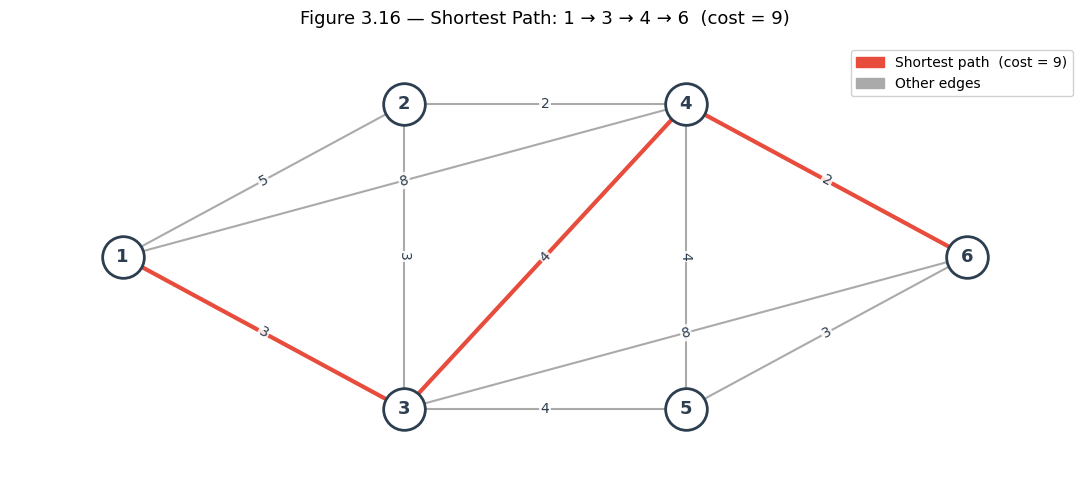

In [5]:
# ========================================
# Draw the network (book example — Figure 3.16)
# Shortest-path edges highlighted in red
# ========================================

sp_set   = set(zip(dijk_path, dijk_path[1:])) | set(zip(dijk_path[1:], dijk_path))
non_sp   = [(u, v) for u, v in G.edges() if (u, v) not in sp_set and (v, u) not in sp_set]
sp_edges = [(u, v) for u, v in G.edges() if (u, v) in sp_set or (v, u) in sp_set]

# Book layout — Figure 3.16 style
pos_book = {
    1: (0,  0),
    2: (2,  1.5),
    3: (2, -1.5),
    4: (4,  1.5),
    5: (4, -1.5),
    6: (6,  0),
}

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('white')

draw_kw = dict(ax=ax)
nx.draw_networkx_edges(G, pos_book, edgelist=non_sp,
                       edge_color='#aaaaaa', width=1.5, **draw_kw)
nx.draw_networkx_edges(G, pos_book, edgelist=sp_edges,
                       edge_color='#e74c3c', width=3.0, **draw_kw)
nx.draw_networkx_nodes(G, pos_book, node_color='white', node_size=900,
                       edgecolors='#2c3e50', linewidths=2.0, ax=ax)
nx.draw_networkx_labels(G, pos_book, font_color='#2c3e50',
                        font_weight='bold', font_size=13, ax=ax)
nx.draw_networkx_edge_labels(
    G, pos_book,
    edge_labels={(u, v): d['weight'] for u, v, d in G.edges(data=True)},
    font_size=10, font_color='#2c3e50',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1.0), ax=ax)

xs = [x for x, _ in pos_book.values()]
ys = [y for _, y in pos_book.values()]
ax.set_xlim(min(xs) - 0.8, max(xs) + 0.8)
ax.set_ylim(min(ys) - 0.7, max(ys) + 0.6)

path_str = ' → '.join(str(n) for n in dijk_path)
red_patch  = mpatches.Patch(color='#e74c3c', label=f'Shortest path  (cost = {dijk_length})')
gray_patch = mpatches.Patch(color='#aaaaaa', label='Other edges')
ax.legend(handles=[red_patch, gray_patch], loc='upper right', fontsize=10, framealpha=0.9)
ax.set_title(f'Figure 3.16 — Shortest Path: {path_str}  (cost = {dijk_length})',
             fontsize=13, pad=14)
ax.axis('off')
plt.tight_layout()
plt.show()
